# Baseline

We build a PCA anomaly detection system to serve as a baseline for the further autoencoder system.

In [1]:
from sklearn.metrics import precision_recall_curve, accuracy_score, precision_score, recall_score, fbeta_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import torch

from common.config import MNIST_RAW_PATH
from common.utils import set_seed
from common.pca_detector import PCAAnomalyDetector
from common.plots import plot_anomaly_distribution, plot_reconstructions
from common.io import load_and_split_mnist

In [2]:
SEED = 42
rs = set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:

train_normal, val_normal, val_anomaly, test_normal, test_anomaly = load_and_split_mnist(
    mnist_path=MNIST_RAW_PATH,
    val_anomaly_digit=8,
    test_anomaly_digit=4,
    random_seed=SEED
)

print("Train splits:")
print(f"train_normal: \tX={train_normal[0].shape}, y={train_normal[1].shape}")

print("\nValidation splits:")
print(f"val_normal:   \tX={val_normal[0].shape}, y={val_normal[1].shape}")
print(f"val_anomaly:  \tX={val_anomaly[0].shape}, y={val_anomaly[1].shape}")

print("\nTest splits:")
print(f"test_normal:  \tX={test_normal[0].shape}, y={test_normal[1].shape}")
print(f"test_anomaly: \tX={test_anomaly[0].shape}, y={test_anomaly[1].shape}")

Train splits:
train_normal: 	X=torch.Size([44304, 784]), y=torch.Size([44304, 10])

Validation splits:
val_normal:   	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
val_anomaly:  	X=torch.Size([974, 784]), y=torch.Size([974, 10])

Test splits:
test_normal:  	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
test_anomaly: 	X=torch.Size([982, 784]), y=torch.Size([982, 10])


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

from typing import Optional

# zooming grid search to optimize pca on n_components and threshold.
def optimize_pca_detector(
    detector_cls: PCAAnomalyDetector,
    train_X: torch.Tensor,
    test_normal_X: torch.Tensor,
    test_anomaly_X: torch.Tensor,
    n_components_min: float,
    n_components_max: float,
    size: int = 4,
    depth: int = 1,
    beta: float = 2.0,
    random_state: Optional[int] = None,
    verbose: bool = False
):
    """
    - detector_cls: The PCA class reference (e.g., PCAAnomalyDetector)
    - train_X: Training features for fitting the detector
    - test_normal_X: Normal test features (in your case, val_normal[0])
    - test_anomaly_X: Anomaly test features (in your case, val_anomaly[0])
    - start_min, start_max: The initial bounds for n_components explained variance
    - size: Number of equally spaced points to sample in the interval
    - depth: How many times to "zoom in" around the best value
    - beta: F-beta weight (e.g. 2.0 for recall priority)
    """

    current_min = n_components_min
    current_max = n_components_max

    # best values across all iterations
    global_best_fbeta = -1.0
    global_best_n = None
    global_best_threshold = None
    global_best_results = {}

    for step in range(depth):
        n_components_grid = np.linspace(current_min, current_max, size)
        
        if verbose:
            print(f"\nZoom Step {step}/{depth} Interval: [{current_min:.4f}, {current_max:.4f}]")
            print(f"{'n_comp':<8} | {'Best Thr':<10} | {'Precision':<10} | {'Recall':<10} | {'F-beta':<10}")
            print("-" * 60)
        
        local_best_fbeta = -1.0
        local_best_n = None

        for n in n_components_grid:
            n_val = float(n)

            detector = detector_cls(n_components=n_val, random_state=random_state)
            detector.fit(train_X)

            val_normal_scores = detector.score_samples(test_normal_X).cpu().numpy()
            val_anomaly_scores = detector.score_samples(test_anomaly_X).cpu().numpy()

            y_true = np.concatenate([np.zeros_like(val_normal_scores, dtype=int), np.ones_like(val_anomaly_scores, dtype=int)])
            y_scores = np.concatenate([val_normal_scores, val_anomaly_scores])

            precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)
            precision, recall, thresholds = precision[:-1], recall[:-1], pr_thresholds

            fbeta_vals = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-12)

            best_idx = np.nanargmax(fbeta_vals)
            thr = thresholds[best_idx]
            fb = fbeta_vals[best_idx]

            if verbose:
                print(f"{n_val:<8.4f} | {thr:<10.6f} | {precision[best_idx]:<10.4f} | {recall[best_idx]:<10.4f} | {fb:<10.4f}")

            # The best in this zoom layer
            if fb > local_best_fbeta:
                local_best_fbeta = fb
                local_best_n = n_val

            # the absolute global best
            if fb > global_best_fbeta:
                global_best_fbeta = fb
                global_best_n = n_val
                global_best_threshold = thr
                global_best_results = {
                    'y_true': y_true, 'y_scores': y_scores, 'thresholds': thresholds,
                    'fbeta_vals': fbeta_vals, 'val_normal_scores': val_normal_scores, 'val_anomaly_scores': val_anomaly_scores
                }

        # Boundaries update
        step_size = (current_max - current_min) / (size - 1)
        current_min = max(n_components_min, local_best_n - (step_size / 2))
        current_max = min(n_components_max, local_best_n + (step_size / 2))

    return global_best_n, global_best_threshold, global_best_results

best_n, best_threshold, best_results = optimize_pca_detector(
    detector_cls=PCAAnomalyDetector,
    train_X=train_normal[0],
    test_normal_X=val_normal[0],
    test_anomaly_X=val_anomaly[0],
    n_components_min=0.6,
    n_components_max=0.8,
    size=5,
    depth=3,
    beta=2.0,
    random_state=SEED,
    verbose=True
)

print(f"Best n_components: {best_n:.6f}")
print(f"Best Threshold: {best_threshold:.6f}")
print(f"Best F2-score: {best_results['fbeta_vals'].max():.4f}")


Zoom Step 0/3 Interval: [0.6000, 0.8000]
n_comp   | Best Thr   | Precision  | Recall     | F-beta    
------------------------------------------------------------
0.6000   | 0.026793   | 0.3390     | 0.9240     | 0.6869    
0.6500   | 0.024748   | 0.3740     | 0.8932     | 0.6991    
0.7000   | 0.019632   | 0.3342     | 0.9251     | 0.6834    
0.7500   | 0.015922   | 0.3209     | 0.9343     | 0.6759    
0.8000   | 0.013246   | 0.3385     | 0.8984     | 0.6751    

Zoom Step 1/3 Interval: [0.6250, 0.6750]
n_comp   | Best Thr   | Precision  | Recall     | F-beta    
------------------------------------------------------------
0.6250   | 0.026363   | 0.3705     | 0.8943     | 0.6971    
0.6375   | 0.025104   | 0.3604     | 0.9035     | 0.6942    
0.6500   | 0.024748   | 0.3740     | 0.8932     | 0.6991    
0.6625   | 0.024011   | 0.3730     | 0.8943     | 0.6989    
0.6750   | 0.021980   | 0.3448     | 0.9271     | 0.6930    

Zoom Step 2/3 Interval: [0.6438, 0.6562]
n_comp   | Best Thr 

In [5]:
detector = PCAAnomalyDetector(n_components=best_n, random_state=SEED)
detector.fit(train_normal[0])

print(f"Number of components: {detector.n_components_}")

Number of components: 20


Best threshold for F2.0-score: 0.024748
Accuracy:  0.6876
Precision: 0.3738
Recall:    0.8922
F2.0 score:  0.6984

Confusion matrix:
[[2566 1456]
 [ 105  869]]

Classification report:
              precision    recall  f1-score   support

           0     0.9607    0.6380    0.7668      4022
           1     0.3738    0.8922    0.5268       974

    accuracy                         0.6876      4996
   macro avg     0.6672    0.7651    0.6468      4996
weighted avg     0.8463    0.6876    0.7200      4996



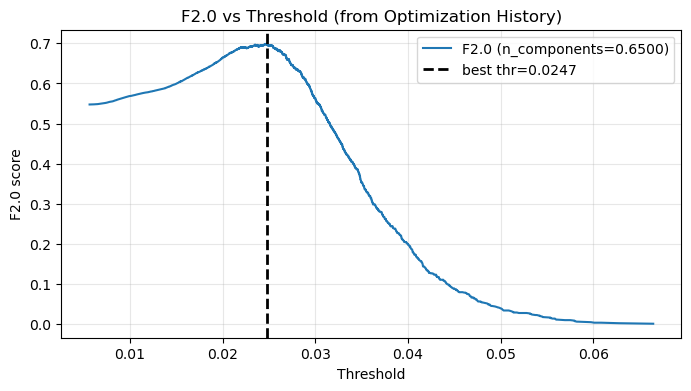

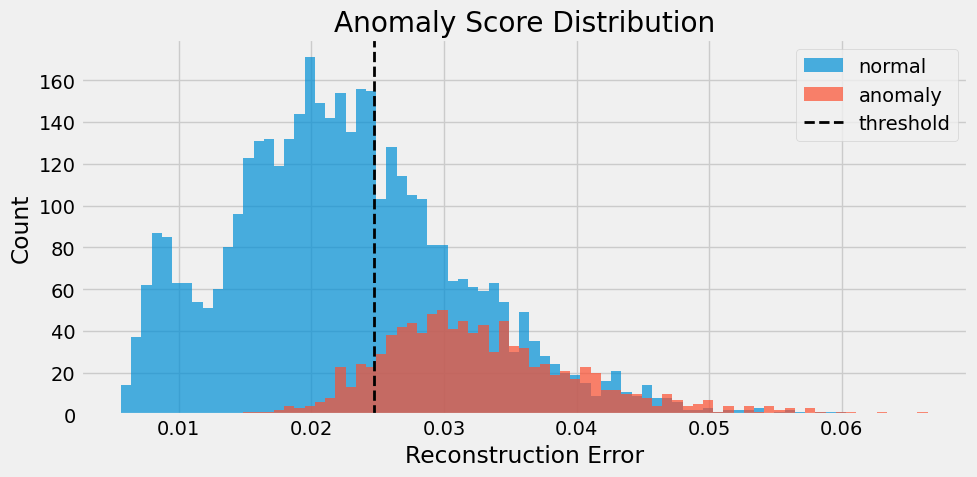

In [6]:
y_true = best_results['y_true']
y_scores = best_results['y_scores']
thresholds = best_results['thresholds']
fbeta_vals = best_results['fbeta_vals']
val_normal_np = best_results['val_normal_scores']
val_anomaly_np = best_results['val_anomaly_scores']

beta = 2.0
y_pred = (y_scores > best_threshold).astype(int)

# Print metrics
print(f'Best threshold for F{beta}-score: {best_threshold:.6f}')
print(f'Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
print(f'Precision: {precision_score(y_true, y_pred):.4f}')
print(f'Recall:    {recall_score(y_true, y_pred):.4f}')
print(f'F{beta} score:  {fbeta_score(y_true, y_pred, beta=beta):.4f}')
print('\nConfusion matrix:')
print(confusion_matrix(y_true, y_pred))
print('\nClassification report:')
print(classification_report(y_true, y_pred, digits=4))

# Plot Fbeta curve
plt.figure(figsize=(8, 4))
plt.plot(thresholds, fbeta_vals, label=f'F{beta} (n_components={best_n:.4f})')
plt.axvline(best_threshold, color='black', linestyle='--', linewidth=2, label=f'best thr={best_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel(f'F{beta} score')
plt.title(f'F{beta} vs Threshold (from Optimization History)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot anomaly distribution
fig = plot_anomaly_distribution(val_normal_np, val_anomaly_np, best_threshold)

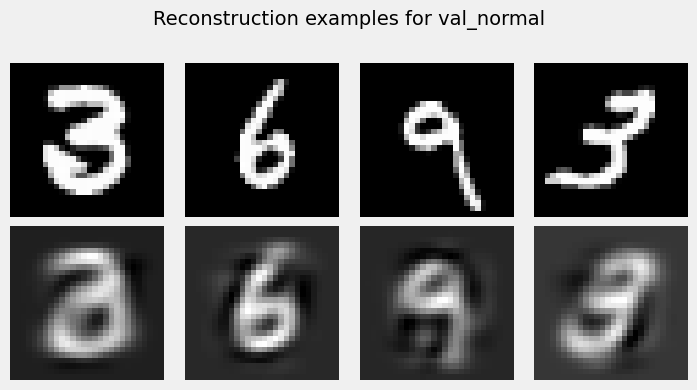

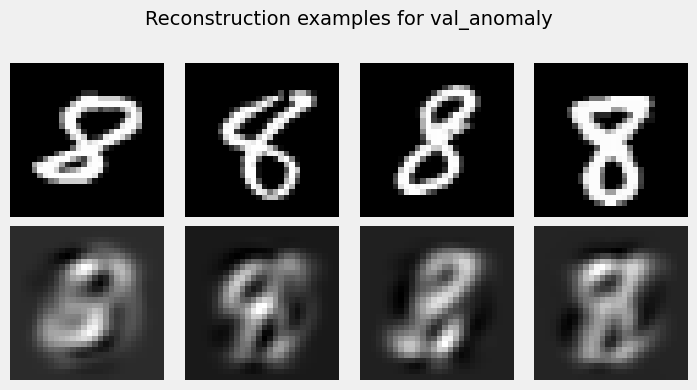

In [7]:
val_normal_recon = detector.reconstruct(val_normal[0])
val_anomaly_recon = detector.reconstruct(val_anomaly[0])

plot_reconstructions(val_normal[0].numpy(), val_normal_recon.numpy(), 'Reconstruction examples for val_normal')

plot_reconstructions(val_anomaly[0].numpy(), val_anomaly_recon.numpy(), 'Reconstruction examples for val_anomaly')